# Imaging, part 5: sampling the posterior

Parts 2–4 found one image, the maximum a posteriori (MAP). It doesn't say how sure we should be of any feature in it: is that knot real, or is the gap in the ring significant? Answering that needs the **posterior**, the distribution of images consistent with the data and the prior. This part draws images from it with numpyro's No-U-Turn Sampler (NUTS) and maps their **mean** and **standard deviation**, pixel by pixel.

The Gaussian-process prior of part 3 is what makes this practical. Its latents have standard-normal priors, so the posterior is smooth and close to Gaussian near the MAP. Sampling an image of thousands of pixels is still slow if done naively, because the data pin down some directions in image space far more tightly than others. The fix is to give NUTS the shape of the posterior in advance, through `gauss_newton_mass`, and that is the main idea of this part.

Sampling needs float64, so the first cell switches it on.

In [1]:
import sys
import time
from pathlib import Path

import jax

jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import numpy as onp
import numpyro.distributions as dist
from numpyro.diagnostics import effective_sample_size
from numpyro.infer import MCMC, NUTS, init_to_value
from tqdm.auto import tqdm

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from drpangloss.coverage import ami_grid_record
from drpangloss.fields import GaussianField
from drpangloss.fitting import fit, gauss_newton_mass
from drpangloss.imaging import beam, image_priors, starting_image
from drpangloss.likelihood import numpyro_model
from drpangloss.models import Image, PointSource, System
from drpangloss.oidata import OIData
from drpangloss.plotting import plot_model, plot_residual_map
from drpangloss.scenes import ring

# The same scene and data as parts 1-3.
template = OIData(ami_grid_record(wavelength_m=4.8e-6, rotation_deg=-6.9))
npix, pixel_scale = 64, 20.0
fov = npix * pixel_scale
truth_image = ring(npix, pixel_scale, radius_mas=240.0, width_mas=36.0, inc_deg=50.0, pa_deg=30.0, asymmetry=0.6, asymmetry_pa_deg=90.0)
truth = System(star=PointSource(), dust=Image.from_brightness(truth_image, pixel_scale, flux=0.05))
data = template.with_model(truth, key=jax.random.PRNGKey(1))
resolution = beam(data)
start = starting_image(data, largest_mas=fov, hole_mas=0.5 * resolution.minor_mas)
n, h = start.env.log_brightness.shape[0], start.env.pixel_scale_mas
print(f"{n}² = {n * n} pixels, {int(data.flatten_data()[0].size)} data")

62² = 3844 pixels, 588 data


## The MAP, at the evidence's σ and ℓ

Part 3's evidence chose σ = 4 and ℓ equal to the beam's minor axis. Here they are held fixed at those values, which is empirical Bayes. The free parameters are the field's latents and the image's flux, as in part 3, and `fit` finds the MAP with Levenberg–Marquardt. The sampler starts there.

In [2]:
sigma, length = 4.0, resolution.minor_mas
field = GaussianField(onp.zeros((n, n)), sigma, length, mean=onp.asarray(start.env.brightness))
scene = System(star=PointSource(), env=Image(field, h, support=start.env.support, flux=start.env.flux))
priors = image_priors(scene) | {"env.flux": dist.Uniform(0.0, 1.0)}
result = fit(scene, priors, data)
print(f"MAP: converged {result.info['converged']} in {result.info['steps']} steps; chi2 per point {result.info['chi2_red']:.2f}; flux {float(result.values['env.flux']):.4f} (truth 0.05); σ = {sigma}, ℓ = {length:.0f} mas")

MAP: converged True in 52 steps; chi2 per point 0.95; flux 0.0503 (truth 0.05); σ = 4.0, ℓ = 131 mas


## Why plain NUTS is slow, and the mass matrix that fixes it

NUTS simulates a particle sliding on the surface of the negative log posterior. Its step size must suit the posterior's narrowest direction. Here that is a combination of latents fixed tightly by the data, or the image's flux, which is measured to about 1%. Its trajectory must also cross the widest direction: latents the data barely touch, which keep their unit prior width. With 588 precise data, the ratio of the two widths is in the hundreds, and NUTS runs to its limit of 1023 steps per draw. On this scene that took 4 minutes on an A100 GPU, and about 20 on a laptop.

The **mass matrix** fixes this by rescaling the space before the particle moves. If its inverse equals the posterior covariance, every direction has unit width, and short trajectories suffice. Near the MAP the posterior is close to a Gaussian whose precision is the Gauss–Newton matrix JᵀJ, where J is the Jacobian of the whitened residuals (the data's and the priors') with respect to the sampled coordinates. `gauss_newton_mass` computes (JᵀJ)⁻¹ at the MAP and returns NUTS's arguments. It switches off NUTS's own estimate of the mass matrix during warmup, because a covariance estimated from a few hundred draws in thousands of dimensions is far worse.

This is why σ and ℓ are fixed here: JᵀJ depends on them, so a matrix computed at one σ and ℓ fits badly when they move.

In [3]:
t0 = time.time()
mcmc = MCMC(
    NUTS(numpyro_model(result.model, priors, data), init_strategy=init_to_value(values=result.values), **gauss_newton_mass(scene, priors, data, result.values)),
    num_warmup=300,
    num_samples=300,
    progress_bar=False,
)
mcmc.run(jax.random.PRNGKey(0), extra_fields=("num_steps", "diverging"))
samples = mcmc.get_samples()
steps = onp.asarray(mcmc.get_extra_fields()["num_steps"])
print(f"300 warmup + 300 draws in {time.time() - t0:.0f} s; median {onp.median(steps):.0f} leapfrog steps per draw (at most 1023); {int(mcmc.get_extra_fields()['diverging'].sum())} divergences")

300 warmup + 300 draws in 407 s; median 63 leapfrog steps per draw (at most 1023); 0 divergences


## Are the draws trustworthy?

Successive NUTS draws are correlated, so 300 draws are worth fewer independent ones. The **effective sample size** (ESS) measures how many. A few hundred is ample for a mean and a standard deviation. Here it is computed for the flux and for every latent. NUTS draws can be anticorrelated, so the ESS can exceed the number of draws.

In [4]:
flux = onp.asarray(samples["env.flux"])
latent = onp.asarray(samples["env.log_brightness.latent"]).reshape(len(flux), -1)
ess = effective_sample_size(latent[None])
low, mid, high = onp.percentile(flux, [5, 50, 95])
print(f"flux {mid:.4f} (90%: {low:.4f}–{high:.4f}; truth 0.05), ESS {float(effective_sample_size(flux[None])):.0f}; latent ESS: 5th percentile {onp.percentile(ess, 5):.0f}, median {onp.median(ess):.0f} of 300")

flux 0.0503 (90%: 0.0500–0.0507; truth 0.05), ESS 334; latent ESS: 5th percentile 473, median 754 of 300


## The posterior mean and standard deviation

Each draw is a complete image. Rendering them all gives the posterior mean, which is a better summary than the MAP (it averages over the images the data allow), and the standard deviation of each pixel.

The third panel is new compared with parts 2–4. With a standard deviation, the difference between the mean and the truth can be shown as a **z-score**, the difference in units of the uncertainty. If the uncertainties are honest, it should look like noise of order one with no structure. Pixels where the posterior has almost no flux, outside the ring and under the star, have almost no spread and are left blank.

The standard-deviation map looks like the mean because the field is in log-brightness. Its uncertainty is fractional, so the absolute spread follows the brightness, and the bright knots on the ring are the most uncertain in absolute terms. The z-scores are mostly within ±1 and show no structure following the ring, which is what honest uncertainties look like. A few pixels at the faint south-western edge reach about −2.5, where the mean is slightly fainter than the truth.

rendering draws:   0%|          | 0/300 [00:00<?, ?it/s]

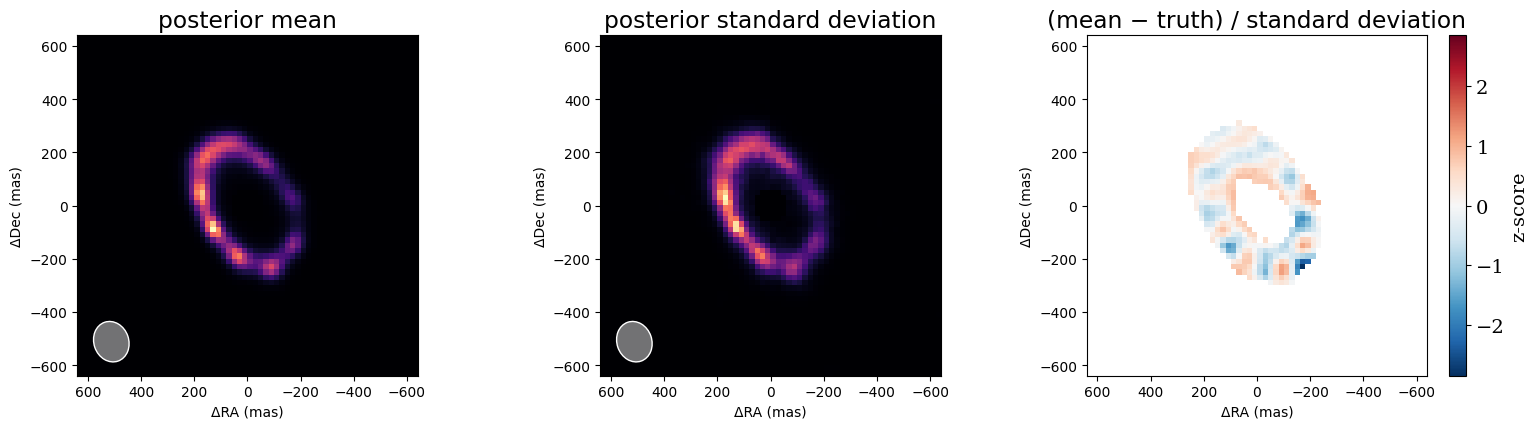

In [5]:
images = onp.stack([onp.asarray(result.model.set("env.log_brightness.latent", z).set("env.flux", f).env.render(npix, fov)) for z, f in zip(tqdm(samples["env.log_brightness.latent"], desc="rendering draws"), samples["env.flux"])])
mean, std = images.mean(0), images.std(0)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
plot_model(Image.from_brightness(mean, pixel_scale, flux=float(mean.sum())), fov_mas=fov, npix=npix, ax=axes[0], title="posterior mean", beam=resolution)
plot_model(Image.from_brightness(std, pixel_scale, flux=float(std.sum())), fov_mas=fov, npix=npix, ax=axes[1], title="posterior standard deviation", beam=resolution)
plot_residual_map(mean - truth_image, fov_mas=fov, sigma=onp.where(std > 0.05 * std.max(), std, onp.nan), ax=axes[2], title="(mean − truth) / standard deviation")
plt.tight_layout()
plt.show()

## What about σ and ℓ?

Holding σ and ℓ at the evidence's choice ignores their own uncertainty. Part 3's evidence grid shows how much that matters: if neighbouring σ and ℓ have nearly the same evidence, images drawn at either would do as well. Sampling them too is possible. Give them priors (e.g. log-normal) and run plain NUTS without `gauss_newton_mass`, whose matrix would be wrong as they move. On this scene that took about 4 minutes on an A100 GPU, and gave σ = 3–10 and ℓ = 80–340 mas (90% intervals), consistent with the evidence's choice. Run that on a GPU, or average images over the evidence grid's neighbouring points.

## Summary
- **NUTS on a Gaussian-field image** samples the field's standard-normal latents with `numpyro_model`, starting at the MAP from `fit`.
- **Large images need a mass matrix.** `gauss_newton_mass` turns the MAP's Gauss–Newton curvature into a dense mass matrix. On this 62² image it cut the cost from 1023 to tens of leapfrog steps per draw. Use it with σ and ℓ fixed, and keep every sampled parameter, flux included, in `priors`.
- **The posterior mean and standard deviation** summarise the image and its uncertainty pixel by pixel, and make residuals into z-scores.